<a href="https://colab.research.google.com/github/miriamamin1213-ux/Seed42_Models/blob/main/LLMGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda


Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 5.78MB/s]


Dataset shape: (423, 12)

Final dataset:
Total patients: 423

Class distribution:
HPV Status
0     23
1    400
Name: count, dtype: int64

Train size: 338
Test size: 85

Training class distribution:
HPV Status
0     18
1    320
Name: count, dtype: int64

Test class distribution:
HPV Status
0     5
1    80
Name: count, dtype: int64

Class weights:
tensor([9.3889, 0.5281], device='cuda:0')

Example clinical narrative:
You are a clinician specialising in head and neck cancer (HNC). Your task is to predict the patient's Human Papillomavirus (HPV) status based on clinical, pathological, and treatment information. In head and neck cancer, the tumour stage describes the extent of the primary tumour, the nodal stage describes regional lymph node involvement, and the metastatic stage describes whether distant metastasis is present. Here is a patient who was diagnosed at 51 years of age and is male. The patient is a current smoker and consumes alcohol. Performance status is 0.0. The patient has n

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Epoch 1/100 | Train Loss: 2.2447 | Test Loss: 0.7661
Epoch 10/100 | Train Loss: 0.6766 | Test Loss: 0.9269
Epoch 20/100 | Train Loss: 1.0712 | Test Loss: 1.3589
Epoch 30/100 | Train Loss: 0.7503 | Test Loss: 0.6888
Epoch 40/100 | Train Loss: 0.6315 | Test Loss: 0.8721
Epoch 50/100 | Train Loss: 1.2568 | Test Loss: 0.7600
Epoch 60/100 | Train Loss: 0.8054 | Test Loss: 0.7041
Epoch 70/100 | Train Loss: 0.5982 | Test Loss: 0.4672
Epoch 80/100 | Train Loss: 0.4875 | Test Loss: 1.4960
Epoch 90/100 | Train Loss: 0.9323 | Test Loss: 0.9393
Epoch 100/100 | Train Loss: 0.4459 | Test Loss: 1.2108

Best model loaded from: best_model_gpt2_clinical_generation.pth

Generating test predictions...

Patient 1/85: HPV Positive HPV Positive HPV -> 1
Patient 2/85: HPV Positive Positive Positive HPV -> 1
Patient 3/85: HPV Positive HPV Positive HPV -> 1
Patient 4/85: HPV Positive HPV Positive HPV -> 1
Patient 5/85: HPV Negative HPV Negative HPV -> 0
Patient 6/85: HPV Negative HPV Negative HPV -> 0
Patient 7

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Patient 84/85: HPV Positive HPV Positive HPV -> 1
Patient 85/85: HPV Positive Positive Positive HPV -> 1

Invalid predictions: 0

Classification Report:
              precision    recall  f1-score   support

HPV Negative     0.1471    1.0000    0.2564         5
HPV Positive     1.0000    0.6375    0.7786        80

    accuracy                         0.6588        85
   macro avg     0.5735    0.8187    0.5175        85
weighted avg     0.9498    0.6588    0.7479        85

Balanced Accuracy: 0.8188
F1 Score: 0.7786

True test labels:
HPV Status
1    80
0     5
Name: count, dtype: int64

Predicted labels:
1    51
0    34
Name: count, dtype: int64

Incorrect predictions:

Patient: 5
True label: HPV Positive
Predicted label: HPV Negative

Patient: 6
True label: HPV Positive
Predicted label: HPV Negative

Patient: 8
True label: HPV Positive
Predicted label: HPV Negative

Patient: 13
True label: HPV Positive
Predicted label: HPV Negative

Patient: 16
True label: HPV Positive
Predicted lab

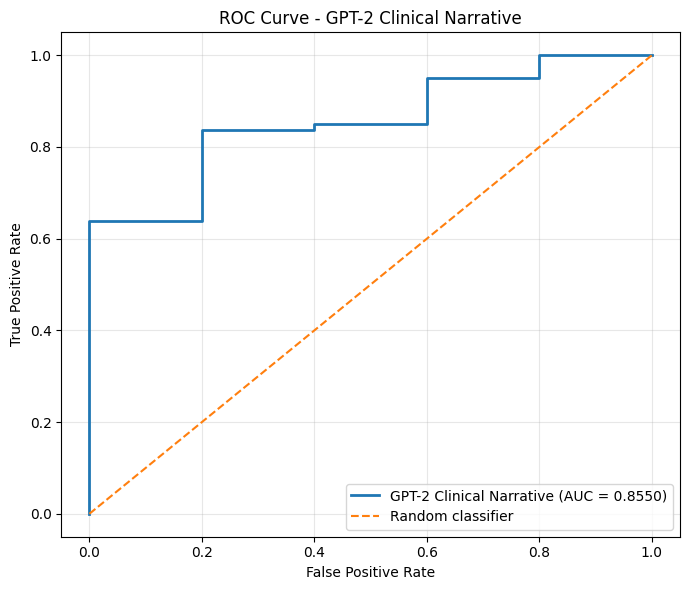


FINAL RESULTS
Dataset: HECKTOR
Model: GPT-2 Clinical Narrative Generation
Seed: 42
Training patients: 338
Test patients: 85
Class weights: Negative = 9.3889, Positive = 0.5281
Learning rate: 0.001
Weight decay: 0.0001
Epochs: 100
Batch size: 8
SMOTE: No
Balanced Accuracy: 0.8187
F1 Score: 0.7786
ROC-AUC: 0.8550


In [5]:
# ============================================================
# GPT-2 Clinical Narrative - HECKTOR
# Text Generation HPV Classification
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import GPT2Tokenizer, GPT2LMHeadModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt


# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

os.environ["PYTHONHASHSEED"] = str(SEED)


# ============================================================
# 2. Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 3. Load HECKTOR Dataset
# ============================================================

import gdown
import pandas as pd

gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

df = pd.read_excel("HPV2025.xlsx")

df = df.dropna(
    subset=["HPV Status"]
)

tobacco_mode = df[
    "Tobacco Consumption"
].mode()[0]

df["Tobacco Consumption"] = (
    df["Tobacco Consumption"]
    .fillna(tobacco_mode)
)

alcohol_mode = df[
    "Alcohol Consumption"
].mode()[0]

df["Alcohol Consumption"] = (
    df["Alcohol Consumption"]
    .fillna(alcohol_mode)
)

df = df.drop(
    columns=[
        "PatientID",
        "CenterID",
        "Task 1",
        "Task 2",
        "Task 3"
    ]
)

df = df.dropna()

print(
    "Dataset shape:",
    df.shape
)

# ============================================================
# 4. Remove missing HPV labels
# ============================================================

df = df.dropna(subset=["HPV Status"]).copy()


# ============================================================
# 5. Fill missing categorical values
# ============================================================

for col in ["Tobacco Consumption", "Alcohol Consumption"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])



# ============================================================
# 7. Drop remaining missing rows
# ============================================================

df = df.dropna().copy()


# ============================================================
# 8. Convert stage variables to numerical values
# ============================================================

def convert_t_stage(value):
    if isinstance(value, str):
        value = value.strip().upper()

        if value.startswith("T"):
            try:
                return int(value[1:])
            except:
                return np.nan

    return value


def convert_n_stage(value):
    if isinstance(value, str):
        value = value.strip().upper()

        if value.startswith("N"):
            try:
                return int(value[1:])
            except:
                return np.nan

    return value


def convert_m_stage(value):
    if isinstance(value, str):
        value = value.strip().upper()

        if value.startswith("M"):
            try:
                return int(value[1:])
            except:
                return np.nan

    return value


df["T-stage"] = df["T-stage"].apply(convert_t_stage)
df["N-stage"] = df["N-stage"].apply(convert_n_stage)
df["M-stage"] = df["M-stage"].apply(convert_m_stage)


# ============================================================
# 9. Select clinical variables
# ============================================================

features = [
    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"
]

target = "HPV Status"

df = df.dropna(
    subset=features + [target]
).copy()


# ============================================================
# 10. Create X and y
# ============================================================

X = df[features].copy()
y = df[target].astype(int).copy()


print("\nFinal dataset:")
print("Total patients:", len(df))

print("\nClass distribution:")
print(y.value_counts().sort_index())


# ============================================================
# 11. Train / Test Split
#     Same 80/20 split and seed as classification model
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)


print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())


# ============================================================
# 12. Calculate Class Weights
# ============================================================

class_counts = np.bincount(y_train)

class_weights = (
    len(y_train)
    / (
        len(class_counts) * class_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("\nClass weights:")
print(class_weights)


# ============================================================
# 13. Helper functions for stage formatting
# ============================================================

def format_t_stage(value):

    value = int(value)

    return f"T{value}"


def format_n_stage(value):

    value = int(value)

    return f"N{value}"


def format_m_stage(value):

    value = int(value)

    return f"M{value}"


# ============================================================
# 14. Convert patient into clinical narrative
# ============================================================

def patient_to_text(row):

    # Gender
    if int(row["Gender"]) == 1:
        gender = "male"
    else:
        gender = "female"

    # Smoking
    if int(row["Tobacco Consumption"]) == 1:
        smoker = "current smoker"
    else:
        smoker = "non-smoker"

    # Alcohol
    if int(row["Alcohol Consumption"]) == 1:
        alcohol = "consumes alcohol"
    else:
        alcohol = "does not consume alcohol"

    # Relapse
    if int(row["Relapse"]) == 1:
        relapse = "has experienced disease relapse"
    else:
        relapse = "has not experienced disease relapse"

    text = (
        "You are a clinician specialising in head and neck cancer (HNC). "
        "Your task is to predict the patient's Human Papillomavirus (HPV) "
        "status based on clinical, pathological, and treatment information. "

        "In head and neck cancer, the tumour stage describes the extent "
        "of the primary tumour, the nodal stage describes regional lymph "
        "node involvement, and the metastatic stage describes whether "
        "distant metastasis is present. "

        f"Here is a patient who was diagnosed at "
        f"{row['Age']:.0f} years of age and is {gender}. "

        f"The patient is a {smoker} and {alcohol}. "

        f"Performance status is {row['Performance Status']}. "

        f"The patient {relapse}. "

        f"Relapse-free survival is {row['RFS']} days. "

        f"Treatment type is {row['Treatment']}. "

        f"The tumour stage is "
        f"{format_t_stage(row['T-stage'])}. "

        f"The nodal stage is "
        f"{format_n_stage(row['N-stage'])}. "

        f"The metastatic stage is "
        f"{format_m_stage(row['M-stage'])}. "

        "Based on the information provided, predict the patient's "
        "Human Papillomavirus (HPV) status. "

        "Respond with exactly one label: "
        "HPV Positive or HPV Negative."
    )

    return text


# ============================================================
# 15. Create clinical narratives
# ============================================================

train_texts = [
    patient_to_text(row)
    for _, row in X_train.iterrows()
]

test_texts = [
    patient_to_text(row)
    for _, row in X_test.iterrows()
]


# ============================================================
# 16. Target text
# ============================================================

train_targets = [
    "HPV Positive" if label == 1 else "HPV Negative"
    for label in y_train
]

test_targets = [
    "HPV Positive" if label == 1 else "HPV Negative"
    for label in y_test
]


print("\nExample clinical narrative:")
print(train_texts[0])

print("\nTarget:")
print(train_targets[0])


# ============================================================
# 17. GPT-2 Tokenizer
# ============================================================

MODEL_NAME = "openai-community/gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(
    MODEL_NAME
)

# GPT-2 does not have a pad token by default
tokenizer.pad_token = tokenizer.eos_token

MAX_LENGTH = 256


# ============================================================
# 18. Dataset
# ============================================================

class GPT2GenerationDataset(Dataset):

    def __init__(
        self,
        texts,
        targets,
        class_labels,
        tokenizer,
        max_length=256
    ):

        self.texts = texts
        self.targets = targets
        self.class_labels = class_labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        prompt = self.texts[idx]
        target = self.targets[idx]

        # Full sequence
        full_text = prompt + " " + target

        # Tokenise prompt separately so we can mask it
        prompt_encoding = self.tokenizer(
            prompt,
            truncation=True,
            max_length=self.max_length,
            add_special_tokens=False
        )

        full_encoding = self.tokenizer(
            full_text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = full_encoding["input_ids"].squeeze(0)

        attention_mask = full_encoding[
            "attention_mask"
        ].squeeze(0)

        labels = input_ids.clone()

        # Number of prompt tokens
        prompt_length = len(
            prompt_encoding["input_ids"]
        )

        # Ignore prompt tokens when calculating loss
        labels[:prompt_length] = -100

        # Ignore padding tokens
        labels[
            attention_mask == 0
        ] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "class_label": torch.tensor(
                self.class_labels[idx],
                dtype=torch.long
            )
        }


# ============================================================
# 19. Create datasets
# ============================================================

train_dataset = GPT2GenerationDataset(
    train_texts,
    train_targets,
    y_train.to_numpy(),
    tokenizer,
    MAX_LENGTH
)

test_dataset = GPT2GenerationDataset(
    test_texts,
    test_targets,
    y_test.to_numpy(),
    tokenizer,
    MAX_LENGTH
)


# ============================================================
# 20. DataLoaders
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 21. GPT-2 Language Model
# ============================================================

model = GPT2LMHeadModel.from_pretrained(
    MODEL_NAME
)

model.config.pad_token_id = tokenizer.pad_token_id

model = model.to(device)


# ============================================================
# 22. Optimizer
#     Same learning rate / weight decay as GPT-2 classifier
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# 23. Weighted GPT-2 Generation Loss
#
#     Important:
#     These are patient-level HPV class weights.
#
#     We do NOT use:
#         CrossEntropyLoss(weight=[9.38, 0.53])
#
#     directly over the GPT-2 vocabulary.
#
#     Instead:
#     1. Calculate normal token-level GPT-2 loss.
#     2. Average it for each patient.
#     3. Multiply the patient's loss by its HPV class weight.
# ============================================================

def weighted_generation_loss(
    logits,
    labels,
    class_labels
):

    # Shift logits and labels for causal language modelling
    shift_logits = logits[
        ..., :-1, :
    ].contiguous()

    shift_labels = labels[
        ..., 1:
    ].contiguous()

    batch_size = shift_logits.size(0)

    vocab_size = shift_logits.size(-1)

    # Calculate loss for every token separately
    loss_fct = nn.CrossEntropyLoss(
        reduction="none"
    )

    token_loss = loss_fct(
        shift_logits.view(
            -1,
            vocab_size
        ),
        shift_labels.view(-1)
    )

    token_loss = token_loss.view(
        batch_size,
        -1
    )

    # Ignore positions where label == -100
    valid_tokens = (
        shift_labels != -100
    ).float()

    # Average loss across target tokens
    token_loss_sum = (
        token_loss * valid_tokens
    ).sum(dim=1)

    token_count = valid_tokens.sum(
        dim=1
    ).clamp(min=1)

    example_loss = (
        token_loss_sum
        / token_count
    )

    # Apply HPV class weight
    example_weights = class_weights[
        class_labels
    ]

    weighted_loss = (
        example_loss
        * example_weights
    )

    # Mean across batch
    loss = weighted_loss.mean()

    return loss


# ============================================================
# 24. Training settings
# ============================================================

EPOCHS = 100

best_test_loss = float("inf")

best_model_path = (
    "best_model_gpt2_clinical_generation.pth"
)


# ============================================================
# 25. Training Loop
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    total_train_loss = 0.0

    for batch in train_loader:

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        class_labels = batch[
            "class_label"
        ].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=None
        )

        loss = weighted_generation_loss(
            outputs.logits,
            labels,
            class_labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += (
            loss.item()
        )

    average_train_loss = (
        total_train_loss
        / len(train_loader)
    )


    # --------------------------------------------------------
    # Test loss
    # --------------------------------------------------------

    model.eval()

    total_test_loss = 0.0

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            class_labels = batch[
                "class_label"
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=None
            )

            loss = weighted_generation_loss(
                outputs.logits,
                labels,
                class_labels
            )

            total_test_loss += (
                loss.item()
            )

    average_test_loss = (
        total_test_loss
        / len(test_loader)
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if average_test_loss < best_test_loss:

        best_test_loss = average_test_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )


    # --------------------------------------------------------
    # Print progress
    # --------------------------------------------------------

    if (
        (epoch + 1) % 10 == 0
        or epoch == 0
    ):

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Test Loss: {average_test_loss:.4f}"
        )


# ============================================================
# 26. Load Best Model
# ============================================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print(
    "\nBest model loaded from:",
    best_model_path
)


# ============================================================
# 27. Generate Prediction
# ============================================================

def generate_prediction(prompt):

    encoding = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    input_ids = encoding[
        "input_ids"
    ].to(device)

    attention_mask = encoding[
        "attention_mask"
    ].to(device)

    with torch.no_grad():

        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # Keep only newly generated tokens
    new_tokens = generated_ids[
        0
    ][
        input_ids.shape[1]:
    ]

    generated_text = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    )

    return generated_text.strip()


# ============================================================
# 28. Extract HPV Label
# ============================================================

def extract_hpv_label(generated_text):

    text = generated_text.lower()

    if "hpv positive" in text:

        return 1

    elif "hpv negative" in text:

        return 0

    else:

        return -1


# ============================================================
# 29. Generate Predictions for Test Set
# ============================================================

predictions = []

print("\nGenerating test predictions...\n")

for i, prompt in enumerate(test_texts):

    generated = generate_prediction(
        prompt
    )

    prediction = extract_hpv_label(
        generated
    )

    predictions.append(
        prediction
    )

    print(
        f"Patient {i + 1}/{len(test_texts)}: "
        f"{generated} -> {prediction}"
    )


# ============================================================
# 30. Convert Predictions to NumPy
# ============================================================

predictions = np.array(
    predictions
)


# ============================================================
# 31. Check Invalid Predictions
# ============================================================

valid = (
    predictions != -1
)

print(
    "\nInvalid predictions:",
    np.sum(~valid)
)


# ============================================================
# 32. Keep Valid Predictions
# ============================================================

y_true = np.array(
    y_test
)[valid]

y_pred = predictions[valid]


# ============================================================
# 33. Classification Report
# ============================================================

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "HPV Negative",
            "HPV Positive"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 34. Balanced Accuracy
# ============================================================

balanced_acc = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_acc,
        4
    )
)


# ============================================================
# 35. F1 Score
# ============================================================

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    "F1 Score:",
    round(
        f1,
        4
    )
)


# ============================================================
# 36. Check Prediction Distribution
# ============================================================

print(
    "\nTrue test labels:"
)

print(
    pd.Series(
        y_test
    ).value_counts()
)


print(
    "\nPredicted labels:"
)

print(
    pd.Series(
        predictions
    ).value_counts()
)


# ============================================================
# 37. Show Incorrect Predictions
# ============================================================

print(
    "\nIncorrect predictions:"
)

for i in range(
    len(y_true)
):

    if y_true[i] != y_pred[i]:

        true_label = (
            "HPV Positive"
            if y_true[i] == 1
            else "HPV Negative"
        )

        predicted_label = (
            "HPV Positive"
            if y_pred[i] == 1
            else "HPV Negative"
        )

        print(
            f"\nPatient: {i + 1}"
        )

        print(
            "True label:",
            true_label
        )

        print(
            "Predicted label:",
            predicted_label
        )


# ============================================================
# 38. Calculate HPV Probability Score
#
#     Generation itself gives us a useful continuous score:
#
#     score =
#       likelihood of "HPV Positive"
#       -
#       likelihood of "HPV Negative"
#
#     This is used for ROC-AUC.
# ============================================================

def get_hpv_scores(prompts):

    scores = []

    model.eval()

    for i, prompt in enumerate(prompts):

        # ----------------------------------------------------
        # Tokenise prompt
        # ----------------------------------------------------

        prompt_encoding = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH
        )

        prompt_ids = prompt_encoding[
            "input_ids"
        ].to(device)

        prompt_mask = prompt_encoding[
            "attention_mask"
        ].to(device)


        candidate_scores = {}


        # ----------------------------------------------------
        # Compare the two possible answers
        # ----------------------------------------------------

        for candidate in [
            "HPV Positive",
            "HPV Negative"
        ]:

            target_encoding = tokenizer(
                " " + candidate,
                return_tensors="pt"
            )

            target_ids = target_encoding[
                "input_ids"
            ].to(device)


            # Append candidate to prompt
            input_ids = torch.cat(
                [
                    prompt_ids,
                    target_ids
                ],
                dim=1
            )

            attention_mask = torch.ones_like(
                input_ids
            )


            # ------------------------------------------------
            # Only calculate loss on candidate tokens
            # ------------------------------------------------

            labels = input_ids.clone()

            labels[
                :,
                :prompt_ids.shape[1]
            ] = -100


            # ------------------------------------------------
            # GPT-2 loss
            # ------------------------------------------------

            with torch.no_grad():

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )


            # Lower loss = more likely candidate
            candidate_scores[
                candidate
            ] = -outputs.loss.item()


        # ----------------------------------------------------
        # Positive score - Negative score
        # ----------------------------------------------------

        score = (
            candidate_scores[
                "HPV Positive"
            ]
            -
            candidate_scores[
                "HPV Negative"
            ]
        )

        scores.append(
            score
        )

        print(
            f"Patient {i + 1}/{len(prompts)} | "
            f"Score: {score:.4f}"
        )


    return np.array(
        scores
    )


# ============================================================
# 39. Calculate ROC-AUC
# ============================================================

auc_scores = get_hpv_scores(
    test_texts
)


auc = roc_auc_score(
    np.array(y_test),
    auc_scores
)

print(
    "\nROC-AUC:",
    round(auc, 4)
)


# ============================================================
# 40. ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(
    np.array(y_test),
    auc_scores
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"GPT-2 Clinical Narrative "
          f"(AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - GPT-2 Clinical Narrative"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 41. Final Summary
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(
    f"Dataset: HECKTOR"
)

print(
    f"Model: GPT-2 Clinical Narrative Generation"
)

print(
    f"Seed: {SEED}"
)

print(
    f"Training patients: {len(y_train)}"
)

print(
    f"Test patients: {len(y_test)}"
)

print(
    f"Class weights: "
    f"Negative = {class_weights[0].item():.4f}, "
    f"Positive = {class_weights[1].item():.4f}"
)

print(
    f"Learning rate: 0.001"
)

print(
    f"Weight decay: 0.0001"
)

print(
    f"Epochs: {EPOCHS}"
)

print(
    f"Batch size: {BATCH_SIZE}"
)

print(
    f"SMOTE: No"
)

print(
    f"Balanced Accuracy: {balanced_acc:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

print(
    f"ROC-AUC: {auc:.4f}"
)

print("=" * 60)